<a href="https://colab.research.google.com/github/cccontre1/DIADM/blob/main/Copia_de_PROYECTO_DIADM_MEDGEMA_VERSION_FINAL_ENUNCIADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final Deep Learning DIADM

En el proyecto final trabajaremos **en grupos de hasta 3 alumnos** con **Med-Gemma**, un modelo multimodal de Google basado en el VLM Gemma, capaz de procesar imágenes médicas junto con texto clínico.

El objetivo es realizar un **estudio de ablación** (donde se sacan algunos componentes del modelo para conocer su importancia), siguiendo la misma metodología del trabajo de [Restrepo et al.](https://arxiv.org/pdf/2508.00171), donde se evalúa el rendimiento del modelo bajo diferentes configuraciones de entrada:
- Imagen + texto originales.
- Imagen original + texto reemplazado por otro de una clase distinta.
- Imagen reemplazada por otra de una clase distinta + texto original.

El propósito de este proyecto es evaluar la robustez del modelo Med-Gemma a través de **replicar los resultados del paper** y analizar empíricamente si el modelo es capaz de leer la señal correcta para responder la pregunta clínica.


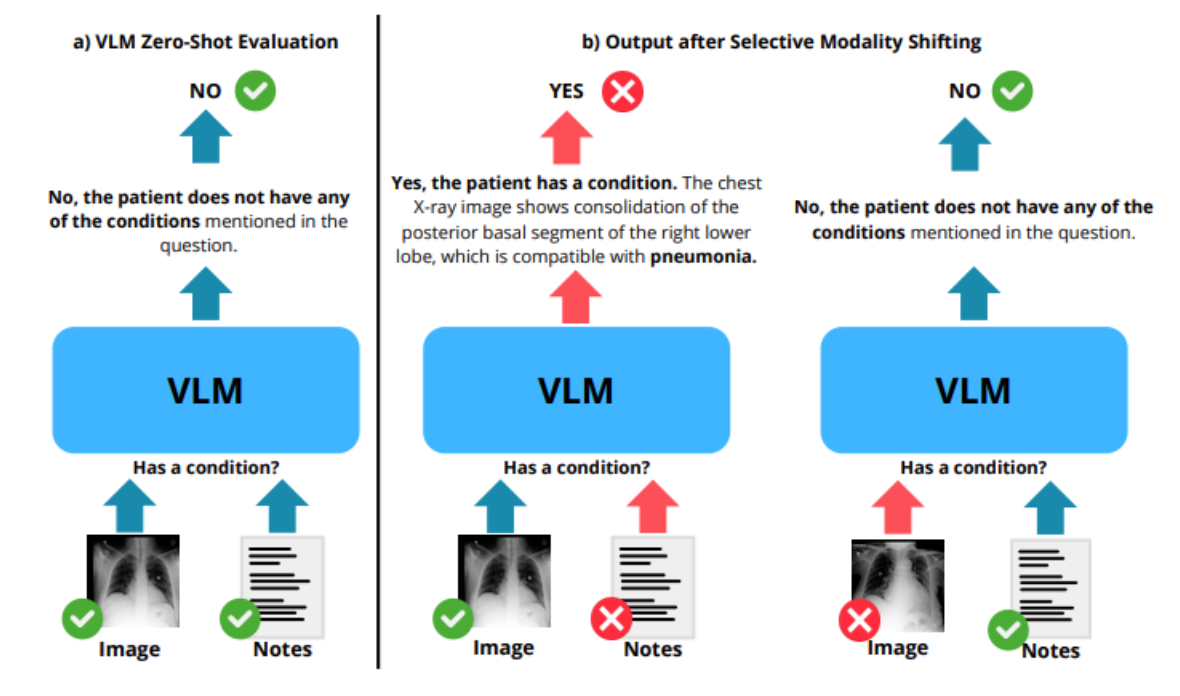

**Figura 1.** Esquema de evaluación del trabajo de Restrepo. En el setting original, **a)** el Vision Language Model (VLM) recibe la imagen y el texto clínico del reporte radiológico para predecir la condición del paciente en un escenario zero-shot (sin entrenamiento). En los otros dos grupos (Selective Modality Shifting), se altera uno de los dos modos: **(b1) Shifting de texto:** se reemplaza el reporte de texto original por uno de otra categoría; y **(b2) Shifting de imagen:** se sustituye la imagen original por otra de la clase opuesta manteniendo el texto intacto. En ambos casos, el VLM vuelve a generar la predicción.

In [ ]:
import os
import json
import re
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import pipeline
from PIL import Image
import torch
import time

Cargar dataset de imágenes y reportes radiológicos de indiana university llamado Open-IU

In [ ]:
!gdown 10ZSJtQCBau7ofqYb46yDBR3Q1I4sv5Tn

Downloading...
From (original): https://drive.google.com/uc?id=10ZSJtQCBau7ofqYb46yDBR3Q1I4sv5Tn
From (redirected): https://drive.google.com/uc?id=10ZSJtQCBau7ofqYb46yDBR3Q1I4sv5Tn&confirm=t&uuid=85b4d476-9fbd-49c7-9b98-6d6a3d241d90
To: /content/Copia de archive.zip
100% 14.1G/14.1G [03:35<00:00, 65.5MB/s]


**NOTA:** *Sólo en caso que la linea anterior te falle, intenta bajar los archivos con este código alternativo (debes agregar una celda nueva al notebook que permita ejecutar código):*

!huggingface-cli download \
  afcarvallo/curso_ihealth \
  "Copia de archive.zip" \
  --repo-type dataset \
  --local-dir .

# Descomprimir imagenes y los resportes de texto en carpeta
Ejecutar la siguiente celda puede tomar varios minutos.


In [ ]:
!unzip '/content/Copia de archive.zip'

Se truncaron las últimas líneas 5000 del resultado de transmisión.
  inflating: images/images_normalized/219_IM-0799-1001.dcm.png  
  inflating: images/images_normalized/219_IM-0799-2001.dcm.png  
  inflating: images/images_normalized/21_IM-0729-1001-0001.dcm.png  
  inflating: images/images_normalized/21_IM-0729-1001-0002.dcm.png  
  inflating: images/images_normalized/2200_IM-0811-1001.dcm.png  
  inflating: images/images_normalized/2200_IM-0811-2001.dcm.png  
  inflating: images/images_normalized/2201_IM-0811-1002.dcm.png  
  inflating: images/images_normalized/2202_IM-0811-1001.dcm.png  
  inflating: images/images_normalized/2202_IM-0811-1002.dcm.png  
  inflating: images/images_normalized/2203_IM-0812-1001.dcm.png  
  inflating: images/images_normalized/2203_IM-0812-2001.dcm.png  
  inflating: images/images_normalized/2204_IM-0813-1001.dcm.png  
  inflating: images/images_normalized/2204_IM-0813-1002.dcm.png  
  inflating: images/images_normalized/2205_IM-0814-1001.dcm.png  
  inf

Tu estructura de carpetas deberia verse como sigue:

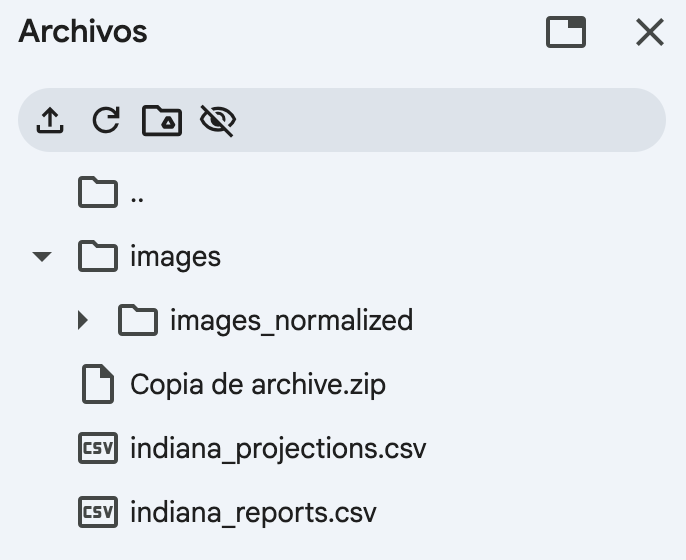

Acontinuación vas a cargar el HF_TOKEN de hugginface. Para ejecutar la siguiente linea debes tener una cuenta en hugging face

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

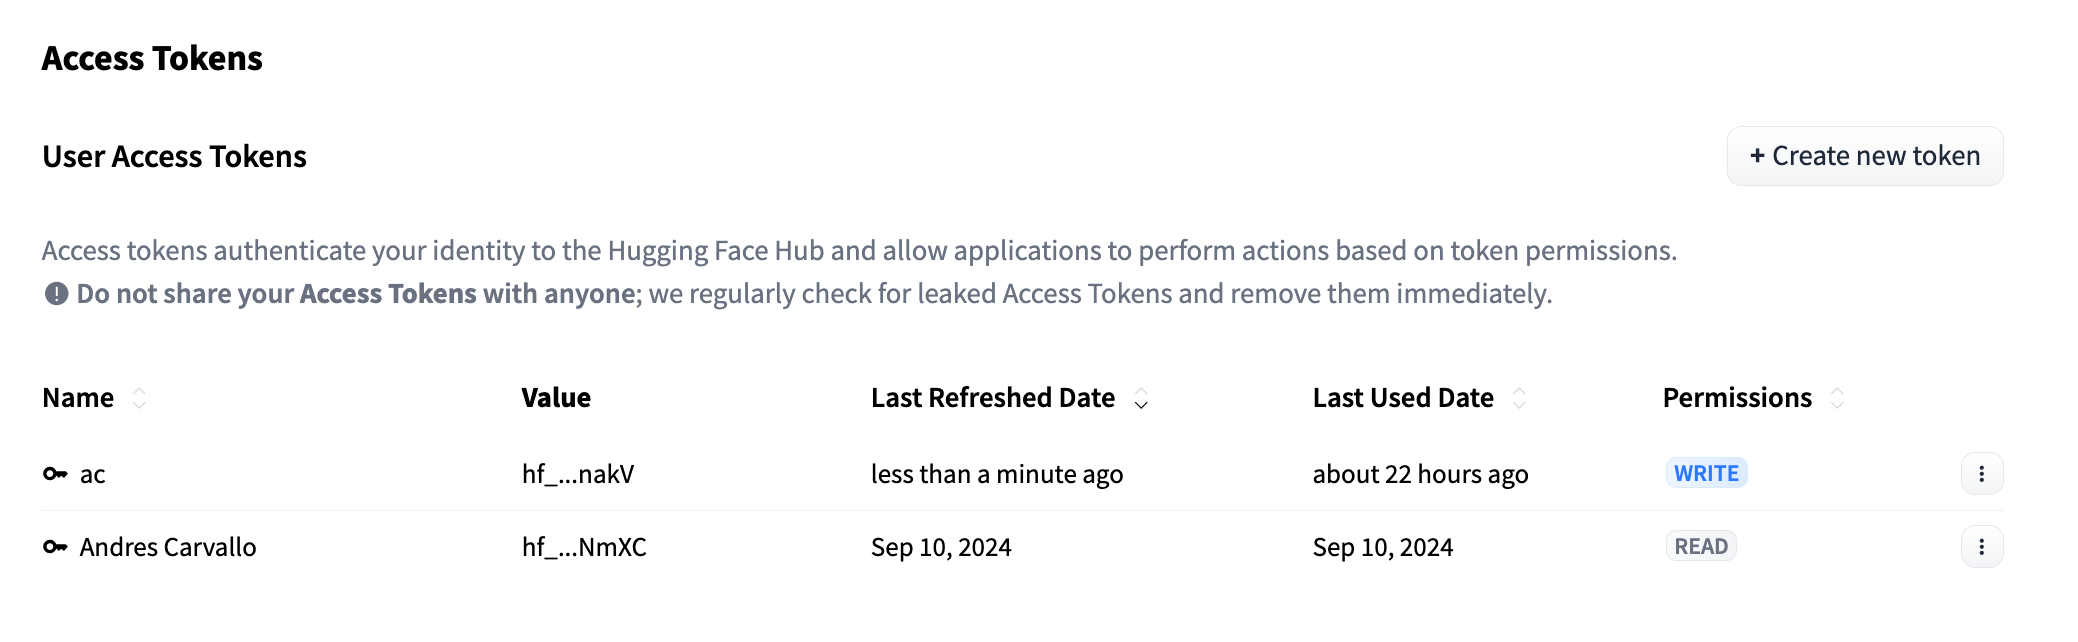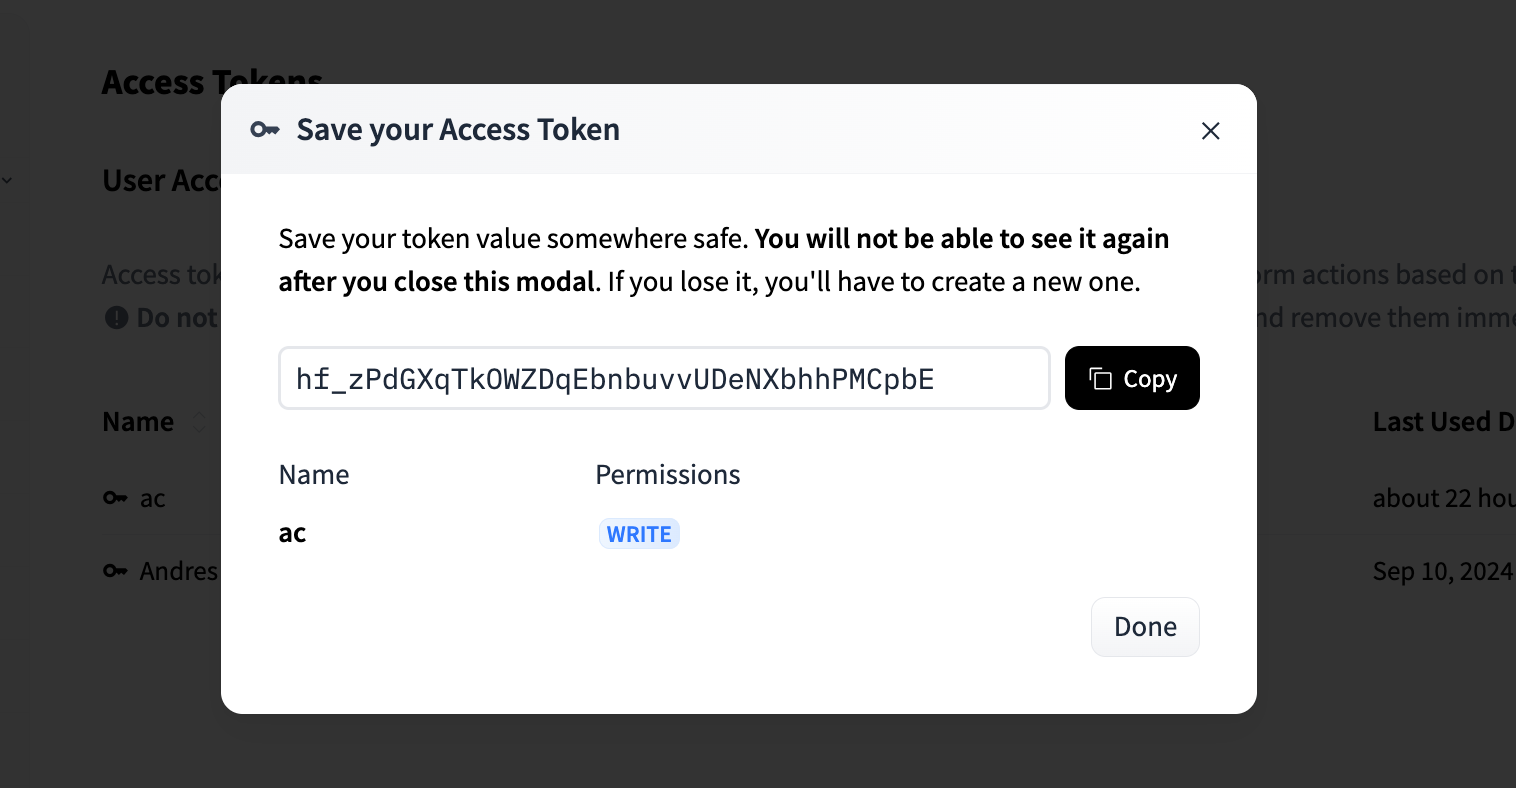

Las siguientes funciones son para cargar las imagenes , hacer las predicciones y compilar los resultados

In [ ]:
def extract_im_section(filename):
    index = filename.find("IM-")
    if index != -1:
        return filename[index:]
    return None


def load_image_and_findings(row, image_directory):
    findings = row["findings"] if isinstance(row["findings"], str) else ""

    image_path = os.path.join(image_directory, row['filename'])

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    img = Image.open(image_path)
    img.thumbnail((512, 512))

    return img, findings


def parse_json_response(response_text):
    try:
        # Try to extract JSON from the response
        json_match = re.search(r'\{[^}]+\}', response_text, re.DOTALL)
        if json_match:
            json_str = json_match.group(0)
            return json.loads(json_str)
    except:
        pass

    # Fallback: try to extract normal_or_disease from text
    response_lower = response_text.lower()
    if 'normal' in response_lower and 'disease' not in response_lower:
        return {'normal_or_disease': 'NORMAL'}
    elif 'disease' in response_lower or 'no normal' in response_lower:
        return {'normal_or_disease': 'DISEASE'}

    return {'normal_or_disease': 'UNKNOWN'}


def medgemma_predict(pipe, img, findings_text, gt_normal, setting=1):
    img_small = img.copy()
    img_small.thumbnail((512, 512))

    prompt_text = (
        "Analyze BOTH the chest X-ray image and the FINDINGS text.\n\n"
        "Return a JSON output with the following fields:\n"
        "- 'normal_or_disease': either 'NORMAL' or 'DISEASE' (based on whether the chest X-ray shows normal findings or disease)\n\n"
        f"FINDINGS:\n{findings_text}\n\n"
        "Respond ONLY with valid JSON."
    )

    messages = [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": "You are an expert radiologist."}
            ]
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": prompt_text
                },
                {"type": "image", "image": img_small}
            ]
        }
    ]

    try:
        output = pipe(text=messages, max_new_tokens=150)
        prediction_text = output[0]["generated_text"][-1]["content"]
        return prediction_text
    except Exception as e:
        print(f"Error in prediction: {e}")
        return "ERROR"


def load_and_process_data():
    df_reports = pd.read_csv('indiana_reports.csv')
    df_image = pd.read_csv('indiana_projections.csv')
    df_image['match_filename'] = df_image['filename'].apply(extract_im_section)
    df_merged = pd.merge(df_reports, df_image, on='uid')
    df_merged.dropna(subset=['findings', 'indication'], inplace=True)
    df_merged['image_path'] = df_merged['filename'].apply(
        lambda x: os.path.join('images/images_normalized', x)
    )
    label2id_projection = {label: idx for idx, label in enumerate(df_merged['projection'].unique())}
    id2label_projection = {idx: label for label, idx in label2id_projection.items()}
    df_merged['label_projection'] = df_merged['projection'].map(label2id_projection)
    df_merged['label_type'] = df_merged['Problems'].apply(
        lambda x: 0 if str(x).lower().strip() == 'normal' else 1
    )

    return df_merged


def load_model():
    pipe = pipeline(
        "image-text-to-text",
        model="google/medgemma-4b-it",
        torch_dtype=torch.bfloat16,
        device="cuda" if torch.cuda.is_available() else "cpu",
    )
    print("Model loaded successfully!")
    return pipe


def print_csv_results(csv_file):
    if not os.path.exists(csv_file):
        print(f"File not found: {csv_file}")
        return

    df = pd.read_csv(csv_file)

    if 'correct' in df.columns:
        accuracy = df['correct'].mean()
        print(f"\nAccuracy: {accuracy:.2%}")
        print(f"Total samples: {len(df)}")
        print(f"Correct predictions: {df['correct'].sum()}")
        print(f"Incorrect predictions: {(df['correct'] == 0).sum()}")

Escriba código que permita:
1. Revisar las 5 primeras filas del archivo indiana_projections.csv
2. Revisar las 5 primeras filas del archivo indiana_reports.csv
3. Mostrar en pantalla, dado un numero de fila, la imagen del X-ray y el reporte en texto correspondiente (tanto findings como impression)
4. Dada una imagen de rayos X, pedir a MedGemma que genere un reporte radiologico (en inglés)



In [ ]:
# Tu respuesta aquí
#Revisar las 5 primeras filas del archivo indiana_projections.csv
#Revisar las 5 primeras filas del archivo indiana_reports.csv
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# 1. Cargar y revisar las 5 primeras filas del archivo de proyecciones
df_projections = pd.read_csv('indiana_projections.csv')
print("--- Primeras 5 filas de indiana_projections.csv ---")
print(df_projections.head())

# Separador visual en la consola
print("\n" + "="*50 + "\n")

# 2. Cargar y revisar las 5 primeras filas del archivo de reportes
df_reports = pd.read_csv('indiana_reports.csv')
print("--- Primeras 5 filas de indiana_reports.csv ---")
print(df_reports.head())

pd.set_option('display.max_columns', None)  # Muestra todas las columnas
pd.set_option('display.max_colwidth', None) # Muestra el texto completo de cada celda


--- Primeras 5 filas de indiana_projections.csv ---
   uid                filename projection
0    1  1_IM-0001-4001.dcm.png    Frontal
1    1  1_IM-0001-3001.dcm.png    Lateral
2    2  2_IM-0652-1001.dcm.png    Frontal
3    2  2_IM-0652-2001.dcm.png    Lateral
4    3  3_IM-1384-1001.dcm.png    Frontal


--- Primeras 5 filas de indiana_reports.csv ---
   uid  \
0    1   
1    2   
2    3   
3    4   
4    5   

                                                                                                                                                                                                                                                                  MeSH  \
0                                                                                                                                                                                                                                                               normal   
1                                                    

 MOSTRANDO CASO - FILA INDICE: 0 (ID: 1)

[FINDINGS]:
The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.

[IMPRESSION]:
Normal chest x-XXXX.
------------------------------------------------------------


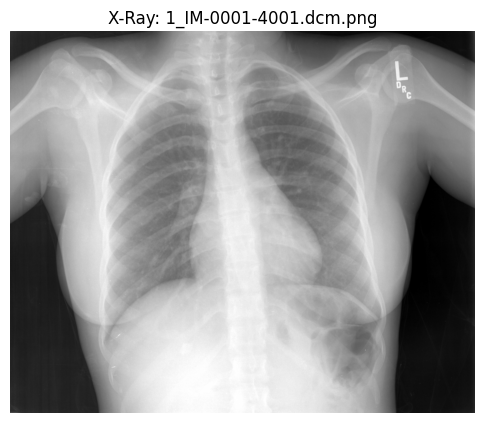

In [ ]:
# Mostrar en pantalla, dado un numero de fila, la imagen del X-ray y el reporte en texto correspondiente (tanto findings como impression)
# 1. Configurar las rutas de tus archivos en Google Colab
PATH_PROJECTIONS = 'indiana_projections.csv'
PATH_REPORTS = 'indiana_reports.csv'
# Ruta absoluta corregida hacia tus imágenes normalizadas
FOLDER_IMAGES = '/content/images/images_normalized'

# 2. Cargar los DataFrames (Asegúrate de que estén en la raíz de /content/ o ajusta su ruta)
df_proj = pd.read_csv(PATH_PROJECTIONS)
df_rep = pd.read_csv(PATH_REPORTS)

def mostrar_caso_por_fila(numero_fila):
    """
    Muestra en pantalla la imagen de rayos X y su reporte clínico
    correspondiente (Findings e Impression) dado un índice de fila.
    """
    if numero_fila < 0 or numero_fila >= len(df_rep) or numero_fila >= len(df_proj):
        print(f"Error: El número de fila {numero_fila} está fuera del rango válido.")
        return

    # 3. Extraer la información de los reportes
    findings = df_rep.iloc[numero_fila].get('findings', 'No especificado')
    impression = df_rep.iloc[numero_fila].get('impression', 'No especificado')
    id_reporte = df_rep.iloc[numero_fila].get('uid', numero_fila)

    # 4. Extraer el nombre de la imagen desde las proyecciones
    nombre_imagen = df_proj.iloc[numero_fila].get('filename', None)

    # 5. Desplegar la información textual
    print("=" * 60)
    print(f" MOSTRANDO CASO - FILA INDICE: {numero_fila} (ID: {id_reporte})")
    print("=" * 60)
    print(f"\n[FINDINGS]:\n{findings}")
    print(f"\n[IMPRESSION]:\n{impression}")
    print("-" * 60)

    # 6. Cargar y mostrar la imagen médica (Ruta de Colab corregida)
    if nombre_imagen:
        # Intentar ruta exacta del CSV
        ruta_completa_imagen = os.path.join(FOLDER_IMAGES, nombre_imagen)
        # Intentar ruta limpia sin el ".dcm" intermedio por si acaso
        ruta_alternativa = os.path.join(FOLDER_IMAGES, nombre_imagen.replace('.dcm.png', '.png'))

        # Validar cuál de las rutas existe en el entorno
        if os.path.exists(ruta_completa_imagen):
            ruta_final = ruta_completa_imagen
        elif os.path.exists(ruta_alternativa):
            ruta_final = ruta_alternativa
        else:
            ruta_final = None
            print(f"Advertencia: No se encontró la imagen en:\n - {ruta_completa_imagen}\n - {ruta_alternativa}")

        # Desplegar visualmente si el archivo existe
        if ruta_final:
            try:
                img = Image.open(ruta_final)

                plt.figure(figsize=(6, 6))
                plt.imshow(img, cmap='gray')  # Escala de grises esencial para radiología
                plt.title(f"X-Ray: {os.path.basename(ruta_final)}")
                plt.axis('off')  # Quitar bordes y coordenadas de píxeles
                plt.show()
            except Exception as e:
                print(f"No se pudo abrir o procesar la imagen: {e}")
    else:
        print("Advertencia: No se encontró un nombre de imagen válido para esta fila.")

# --- Prueba el código ejecutando esta línea ---
mostrar_caso_por_fila(0)

Usando dispositivo: cuda

Descargando y cargando Med-Gemma en la GPU...


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.55k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

¡Modelo cargado exitosamente y listo!

[PROCESANDO FILA 0] Analizando imagen y generando texto...
 DATOS REALES DEL DATASET (FILA 0)
[FINDINGS REAL]:
The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.
[IMPRESSION REAL]:
Normal chest x-XXXX.
------------------------------------------------------------
 REPORTE PREDICHO POR MED-GEMMA 1.5
------------------------------------------------------------
FINDINGS:
The heart size is normal. The mediastinal contours are normal. The lungs are clear without focal consolidation, pleural effusion, or pneumothorax. The osseous structures are unremarkable. IMPRESSION:
No acute cardiopulmonary process.


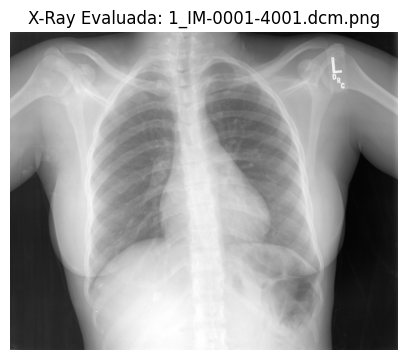

In [ ]:
#Dada una imagen de rayos X, pedir a MedGemma que genere un reporte radiologico (en inglés)
import os
import gc
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText

# 1. Configuración del entorno e higienización de memoria
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

# Limpieza preventiva inicial
gc.collect()
torch.cuda.empty_cache()

# 2. Configuración de rutas del Dataset Indiana (Ajusta si tus CSVs cambian de lugar)
PATH_PROJECTIONS = 'indiana_projections.csv'
PATH_REPORTS = 'indiana_reports.csv'
FOLDER_IMAGES = '/content/images/images_normalized'

# Cargar DataFrames
df_proj = pd.read_csv(PATH_PROJECTIONS)
df_rep = pd.read_csv(PATH_REPORTS)

# 3. Cargar Med-Gemma 1.5 de forma ultra-eficiente
MODEL_ID = "google/medgemma-1.5-4b-it"

print("\nDescargando y cargando Med-Gemma en la GPU...")
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16, # bfloat16 reduce el consumo de VRAM a la mitad
    low_cpu_mem_usage=True,     # Optimiza la carga inicial en RAM
    device_map="auto"
)
print("¡Modelo cargado exitosamente y listo!")

# 4. Función de Inferencia Optimizada para el Estudio de Ablación
def generar_reporte_medgemma_seguro(numero_fila):
    """
    Toma los datos de una fila del dataset, muestra la clínica real,
    y genera el reporte con Med-Gemma de forma determinista y segura en VRAM.
    """
    # Validaciones de índice
    if numero_fila < 0 or numero_fila >= len(df_rep):
        print("Error: Índice de fila fuera de rango.")
        return

    # Extraer datos reales del dataset para contrastar
    findings_real = df_rep.iloc[numero_fila].get('findings', 'No especificado')
    impression_real = df_rep.iloc[numero_fila].get('impression', 'No especificado')
    nombre_imagen = df_proj.iloc[numero_fila].get('filename', None)

    if not nombre_imagen:
        print("Error: No se encontró nombre de imagen para esta fila.")
        return

    ruta_imagen = os.path.join(FOLDER_IMAGES, nombre_imagen)
    # Ruta alternativa sin el .dcm por si acaso
    if not os.path.exists(ruta_imagen):
        ruta_imagen = os.path.join(FOLDER_IMAGES, nombre_imagen.replace('.dcm.png', '.png'))

    if not os.path.exists(ruta_imagen):
        print(f"Error: La imagen no existe en la ruta: {ruta_imagen}")
        return

    # Forzar limpieza antes de procesar la imagen pesada
    gc.collect()
    torch.cuda.empty_cache()

    try:
        # Cargar imagen médica
        raw_image = Image.open(ruta_imagen).convert("RGB")

        # Estructurar el prompt formal para la plantilla de Gemma
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": "Context: Frontal chest radiograph.\nTask: Generate a comprehensive radiology report based on the provided image.\nFormat:\nFINDINGS:\nIMPRESSION:"}
                ]
            }
        ]

        prompt_estructurado = processor.apply_chat_template(messages, add_generation_prompt=True)

        # Preprocesar inputs y pasarlos a bfloat16
        inputs = processor(text=prompt_estructurado, images=raw_image, return_tensors="pt")
        inputs = {k: v.to(device=device, dtype=torch.bfloat16 if v.dtype == torch.float32 else v.dtype) for k, v in inputs.items()}

        print(f"\n[PROCESANDO FILA {numero_fila}] Analizando imagen y generando texto...")

        # Modo inferencia estricto para ahorro de memoria masivo
        with torch.inference_mode():
            generated_ids = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask", None),
                pixel_values=inputs.get("pixel_values", None),
                image_sizes=inputs.get("image_sizes", None),
                max_new_tokens=120,   # Reportes médicos suelen ser concisos
                do_sample=False,      # Determinista para replicar a Restrepo et al.
                pad_token_id=processor.tokenizer.eos_token_id
            )

        # Decodificar respuesta del modelo
        prompt_length = inputs["input_ids"].shape[1]
        generated_text = processor.batch_decode(
            generated_ids[:, prompt_length:],
            skip_special_tokens=True
        )[0]

        # --- DESPLIEGUE COMPARATIVO EN PANTALLA ---
        print("=" * 60)
        print(f" DATOS REALES DEL DATASET (FILA {numero_fila})")
        print("=" * 60)
        print(f"[FINDINGS REAL]:\n{findings_real}")
        print(f"[IMPRESSION REAL]:\n{impression_real}")
        print("-" * 60)
        print(" REPORTE PREDICHO POR MED-GEMMA 1.5")
        print("-" * 60)
        print(generated_text.strip())
        print("=" * 60)

        # Mostrar la imagen que vio el modelo
        plt.figure(figsize=(5, 5))
        plt.imshow(raw_image, cmap='gray')
        plt.title(f"X-Ray Evaluada: {os.path.basename(ruta_imagen)}")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error en la inferencia: {e}")
    finally:
        # Limpieza reactiva
        gc.collect()
        torch.cuda.empty_cache()

# --- Ejecutar la prueba ---
# Una vez cargado todo, solo llamas a la función con la fila que quieras evaluar
generar_reporte_medgemma_seguro(0)

El siguiente bloque de código declara las funciones de experimentación:
- *Original* (ya implementada), y las de
- *image shifting* (**tú debes implementar**), y
- *text shifting* (**tú debes implementar**)

In [ ]:
def run_setting_original(df_test, pipe, image_directory):
    print("\n" + "="*70)
    print("SETTING: ORIGINAL (Original Image + Original Text)")
    print("="*70)

    print(f"[LOG] Processing all {len(df_test)} test samples...")
    results = []
    start_time = time.time()

    for idx, (_, row) in enumerate(df_test.iterrows(), 1):
        try:
            print(f"[LOG] Processing sample {idx}/{len(df_test)}: UID {row['uid']}")

            # Load original image and findings
            print(f"  [LOG] Loading original image: {row['filename']}")
            img, findings_text = load_image_and_findings(row, image_directory)
            print(f"  [LOG] Image loaded. Findings length: {len(findings_text)} chars")

            # Make prediction with original data
            print(f"  [LOG] Making prediction with original image + original text...")
            prediction_text = medgemma_predict(pipe, img, findings_text, row["Problems"], setting=1)
            print(f"  [LOG] Prediction received: {len(prediction_text)} chars")

            # Parse prediction
            parsed = parse_json_response(prediction_text)
            predicted_label = parsed.get('normal_or_disease', 'UNKNOWN')
            predicted_binary = 0 if predicted_label == 'NORMAL' else 1
            true_label = row['label_type']

            is_correct = predicted_binary == true_label
            print(f"  [LOG] True label: {true_label} ({'normal' if true_label == 0 else 'no normal'})")
            print(f"  [LOG] Predicted: {predicted_label} ({'✓' if is_correct else '✗'})")

            results.append({
                'uid': row['uid'],
                'filename': row['filename'],
                'true_label': true_label,
                'true_label_text': 'normal' if true_label == 0 else 'no normal',
                'predicted_label': predicted_binary,
                'predicted_label_text': predicted_label,
                'findings': findings_text[:100] + '...' if len(findings_text) > 100 else findings_text,
                'raw_prediction': prediction_text[:200] + '...' if len(prediction_text) > 200 else prediction_text,
                'correct': 1 if is_correct else 0
            })

        except Exception as e:
            print(f"  [ERROR] Error processing UID {row['uid']}: {e}")
            import traceback
            traceback.print_exc()
            continue

    elapsed_time = time.time() - start_time
    print(f"\n[LOG] Completed processing in {elapsed_time:.2f} seconds")

    df_results = pd.DataFrame(results)

    if len(df_results) > 0:
        y_true = df_results['true_label'].values
        y_pred = df_results['predicted_label'].values

        # Generate sklearn classification report
        report = classification_report(
            y_true, y_pred,
            target_names=['normal', 'no normal'],
            labels=[0, 1],
            output_dict=True,
            zero_division=0
        )

        # Convert to DataFrame for CSV export
        df_report = pd.DataFrame(report).transpose()

        accuracy = df_results['correct'].mean()
        print(f"\n[LOG] Results Summary:")
        print(f"  - Total samples: {len(df_results)}")
        print(f"  - Accuracy: {accuracy:.2%}")
        print(f"  - Correct predictions: {df_results['correct'].sum()}")
        print(f"  - Incorrect predictions: {(df_results['correct'] == 0).sum()}")

        print("\n[LOG] Classification Report (F1, Precision, Recall):")
        print(classification_report(y_true, y_pred, target_names=['normal', 'no normal'], labels=[0, 1], zero_division=0))

        print("\n[LOG] Confusion Matrix:")
        print(confusion_matrix(y_true, y_pred))

        return df_results, df_report

    return pd.DataFrame(), pd.DataFrame()


# COMPLETAR ESTA FUNCION PARA GENERAR UN EXPERIMENTO DONDE SE REEMPLAZAN IMAGENES POR UNAS DE LA OTRA CLASE (label_type diferente)
# Estas funciones se ejecutan al final del archivo
def run_setting_image_shifting(df_test, df_train, pipe, image_directory):
  pass


# COMPLETAR ESTA FUNCION PARA GENERAR UN EXPERIMENTO DONDE SE REEMPLAZAN TEXTOS POR UNOS DE LA OTRA CLASE (label_type diferente)
# Estas funciones se ejecutan al final del archivo
def run_setting_text_shifting(df_test, df_train, pipe, image_directory):
    pass

In [ ]:
# COMPLETAR ESTA FUNCION PARA GENERAR UN EXPERIMENTO DONDE SE REEMPLAZAN IMAGENES POR UNAS DE LA OTRA CLASE (label_type diferente)
# Estas funciones se ejecutan al final del archivo
def run_setting_image_shifting(df_test, df_train, pipe, image_directory):
    print("\n" + "="*70)
    print("SETTING: IMAGE SHIFTING (Mismatched Image + Original Text)")
    print("="*70)

    print(f"[LOG] Processing all {len(df_test)} test samples with shifted images...")
    results = []
    start_time = time.time()

    for idx, (_, row) in enumerate(df_test.iterrows(), 1):
        try:
            print(f"[LOG] Processing sample {idx}/{len(df_test)}: UID {row['uid']}")

            # 1. Identificar la clase opuesta
            true_label = row['label_type']
            opposite_label = 1 if true_label == 0 else 0

            # 2. Buscar candidatos en df_train con la clase opuesta
            candidates = df_train[df_train['label_type'] == opposite_label]
            if candidates.empty:
                print(f"  [ERROR] No candidate images found with opposite label for UID {row['uid']}. Skipping.")
                continue

            # Seleccionar una muestra aleatoria de la otra clase
            sampled_row = candidates.sample(n=1).iloc[0]

            # 3. Cargar la imagen INCORRECTA (sampled) y los hallazgos ORIGINALES (row)
            print(f"  [LOG] Loading MISMATCHED image: {sampled_row['filename']} instead of {row['filename']}")
            img_mismatched, _ = load_image_and_findings(sampled_row, image_directory)

            # Cargamos el texto clínico original correspondente al paciente real
            _, findings_text_original = load_image_and_findings(row, image_directory)
            print(f"  [LOG] Image loaded. Using original findings length: {len(findings_text_original)} chars")

            # 4. Predicción (Configuración: Setting=2 para control interno de logs si corresponde)
            print(f"  [LOG] Making prediction with mismatched image + original text...")
            prediction_text = medgemma_predict(pipe, img_mismatched, findings_text_original, row["Problems"], setting=2)
            print(f"  [LOG] Prediction received: {len(prediction_text)} chars")

            # 5. Parsear la predicción
            parsed = parse_json_response(prediction_text)
            predicted_label = parsed.get('normal_or_disease', 'UNKNOWN')
            predicted_binary = 0 if predicted_label == 'NORMAL' else 1

            # La evaluación de "correcto" sigue contrastándose contra la etiqueta del texto/paciente real
            is_correct = predicted_binary == true_label
            print(f"  [LOG] True label: {true_label} ({'normal' if true_label == 0 else 'no normal'})")
            print(f"  [LOG] Predicted: {predicted_label} ({'✓' if is_correct else '✗'})")

            results.append({
                'uid': row['uid'],
                'filename': row['filename'],
                'mismatched_filename': sampled_row['filename'],
                'true_label': true_label,
                'true_label_text': 'normal' if true_label == 0 else 'no normal',
                'predicted_label': predicted_binary,
                'predicted_label_text': predicted_label,
                'findings': findings_text_original[:100] + '...' if len(findings_text_original) > 100 else findings_text_original,
                'raw_prediction': prediction_text[:200] + '...' if len(prediction_text) > 200 else prediction_text,
                'correct': 1 if is_correct else 0
            })

        except Exception as e:
            print(f"  [ERROR] Error processing UID {row['uid']}: {e}")
            import traceback
            traceback.print_exc()
            continue

    elapsed_time = time.time() - start_time
    print(f"\n[LOG] Completed processing in {elapsed_time:.2f} seconds")

    df_results = pd.DataFrame(results)

    if len(df_results) > 0:
        y_true = df_results['true_label'].values
        y_pred = df_results['predicted_label'].values

        report = classification_report(
            y_true, y_pred,
            target_names=['normal', 'no normal'],
            labels=[0, 1],
            output_dict=True,
            zero_division=0
        )
        df_report = pd.DataFrame(report).transpose()

        accuracy = df_results['correct'].mean()
        print(f"\n[LOG] Results Summary (IMAGE SHIFTING):")
        print(f"  - Total samples: {len(df_results)}")
        print(f"  - Accuracy (matching original text label): {accuracy:.2%}")
        print(f"  - Correct predictions: {df_results['correct'].sum()}")
        print(f"  - Incorrect predictions: {(df_results['correct'] == 0).sum()}")

        print("\n[LOG] Classification Report (F1, Precision, Recall):")
        print(classification_report(y_true, y_pred, target_names=['normal', 'no normal'], labels=[0, 1], zero_division=0))

        print("\n[LOG] Confusion Matrix:")
        print(confusion_matrix(y_true, y_pred))

        return df_results, df_report

    return pd.DataFrame(), pd.DataFrame()

In [ ]:
# COMPLETAR ESTA FUNCION PARA GENERAR UN EXPERIMENTO DONDE SE REEMPLAZAN TEXTOS POR UNOS DE LA OTRA CLASE (label_type diferente)
# Estas funciones se ejecutan al final del archivo
def run_setting_text_shifting(df_test, df_train, pipe, image_directory):
    print("\n" + "="*70)
    print("SETTING: TEXT SHIFTING (Original Image + Mismatched Text)")
    print("="*70)

    print(f"[LOG] Processing all {len(df_test)} test samples with shifted text...")
    results = []
    start_time = time.time()

    for idx, (_, row) in enumerate(df_test.iterrows(), 1):
        try:
            print(f"[LOG] Processing sample {idx}/{len(df_test)}: UID {row['uid']}")

            # 1. Cargar la imagen ORIGINAL del paciente
            print(f"  [LOG] Loading original image: {row['filename']}")
            img_original, _ = load_image_and_findings(row, image_directory)

            # 2. Identificar la clase opuesta para buscar texto contradictorio
            true_label = row['label_type']
            opposite_label = 1 if true_label == 0 else 0

            # 3. Extraer candidatos con reportes clínicos cruzados desde df_train
            candidates = df_train[df_train['label_type'] == opposite_label]
            if candidates.empty:
                print(f"  [ERROR] No candidate reports found with opposite label for UID {row['uid']}. Skipping.")
                continue

            sampled_row = candidates.sample(n=1).iloc[0]

            # Cargamos el texto de hallazgos del caso modificado (sampled_row)
            _, findings_text_mismatched = load_image_and_findings(sampled_row, image_directory)
            print(f"  [LOG] Mismatched findings loaded from UID {sampled_row['uid']}. Length: {len(findings_text_mismatched)} chars")

            # 4. Predicción usando imagen real pero los textos cruzados (Setting=3)
            print(f"  [LOG] Making prediction with original image + mismatched text...")
            # Pasamos tanto las 'Problems' de la fila de entrenamiento cruzada para mantener la coherencia en la perturbación
            prediction_text = medgemma_predict(pipe, img_original, findings_text_mismatched, sampled_row["Problems"], setting=3)
            print(f"  [LOG] Prediction received: {len(prediction_text)} chars")

            # 5. Parsear la predicción
            parsed = parse_json_response(prediction_text)
            predicted_label = parsed.get('normal_or_disease', 'UNKNOWN')
            predicted_binary = 0 if predicted_label == 'NORMAL' else 1

            # Evaluamos contra la etiqueta original de la IMAGEN para ver si el modelo "mira" el hallazgo visual
            is_correct = predicted_binary == true_label
            print(f"  [LOG] True label (Visual): {true_label} ({'normal' if true_label == 0 else 'no normal'})")
            print(f"  [LOG] Predicted: {predicted_label} ({'✓' if is_correct else '✗'})")

            results.append({
                'uid': row['uid'],
                'filename': row['filename'],
                'true_label': true_label,
                'true_label_text': 'normal' if true_label == 0 else 'no normal',
                'predicted_label': predicted_binary,
                'predicted_label_text': predicted_label,
                'mismatched_uid_text': sampled_row['uid'],
                'findings_mismatched': findings_text_mismatched[:100] + '...' if len(findings_text_mismatched) > 100 else findings_text_mismatched,
                'raw_prediction': prediction_text[:200] + '...' if len(prediction_text) > 200 else prediction_text,
                'correct': 1 if is_correct else 0
            })

        except Exception as e:
            print(f"  [ERROR] Error processing UID {row['uid']}: {e}")
            import traceback
            traceback.print_exc()
            continue

    elapsed_time = time.time() - start_time
    print(f"\n[LOG] Completed processing in {elapsed_time:.2f} seconds")

    df_results = pd.DataFrame(results)

    if len(df_results) > 0:
        y_true = df_results['true_label'].values
        y_pred = df_results['predicted_label'].values

        report = classification_report(
            y_true, y_pred,
            target_names=['normal', 'no normal'],
            labels=[0, 1],
            output_dict=True,
            zero_division=0
        )
        df_report = pd.DataFrame(report).transpose()

        accuracy = df_results['correct'].mean()
        print(f"\n[LOG] Results Summary (TEXT SHIFTING):")
        print(f"  - Total samples: {len(df_results)}")
        print(f"  - Accuracy (matching original image label): {accuracy:.2%}")
        print(f"  - Correct predictions: {df_results['correct'].sum()}")
        print(f"  - Incorrect predictions: {(df_results['correct'] == 0).sum()}")

        print("\n[LOG] Classification Report (F1, Precision, Recall):")
        print(classification_report(y_true, y_pred, target_names=['normal', 'no normal'], labels=[0, 1], zero_division=0))

        print("\n[LOG] Confusion Matrix:")
        print(confusion_matrix(y_true, y_pred))

        return df_results, df_report

    return pd.DataFrame(), pd.DataFrame()

Cargar los datos y hacer particion de datos entrenamiento y testing

In [ ]:
import pandas as pd
import os

df_merged = load_and_process_data()

df_train, df_test = train_test_split(
    df_merged,
    test_size=0.01,
    random_state=42,
    stratify=df_merged['label_type']
)

image_directory = "images/images_normalized/"  # Adjust path as needed in Colab


**Ejecutar el siguiente bloque una sola vez porque carga el modelo en memoria RAM, y si se ejecuta dos o más veces te quedarás sin memoria para ejecutar el resto del proyecto.**

NOTA: el siguiente código va a demorar unos minutos


In [ ]:
#pipe = load_model() # esta linea carga el modelo MedGemma
"""no quise correr esta línea porque me bajaría nuevamente el modelo"""

'no quise correr esta línea porque me bajaría nuevamente el modelo'

In [ ]:
from transformers import pipeline

# Construimos el pipeline pasando el procesador unificado directamente
pipe = pipeline(
    "image-text-to-text",
    model=model,
    processor=processor  # Esto le entrega el tokenizador y el codificador visual juntos
)

print("¡Objeto 'pipe' enlazado y configurado exitosamente!")

¡Objeto 'pipe' enlazado y configurado exitosamente!


**A)** Ejecuta el experimento solo en modo normal (sin shifting)

In [ ]:
df_results_original, df_report_original = run_setting_original(df_test, pipe, image_directory)

if len(df_results_original) > 0:
    df_results_original.to_csv('results_original.csv', index=False)
    df_report_original.to_csv('results_original_report.csv', index=True)
    print(f"\n[MAIN] Results saved to results_original.csv")
    print(f"[MAIN] Classification report saved to results_original_report.csv")
    print_csv_results('results_original.csv')
    print_csv_results('results_original_report.csv')


[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



SETTING: ORIGINAL (Original Image + Original Text)
[LOG] Processing all 64 test samples...
[LOG] Processing sample 1/64: UID 2469
  [LOG] Loading original image: 2469_IM-0999-3001.dcm.png
  [LOG] Image loaded. Findings length: 272 chars
  [LOG] Making prediction with original image + original text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [LOG] Prediction received: 47 chars
  [LOG] True label: 1 (no normal)
  [LOG] Predicted: NORMAL (✗)
[LOG] Processing sample 2/64: UID 2151
  [LOG] Loading original image: 2151_IM-0771-1001.dcm.png
  [LOG] Image loaded. Findings length: 257 chars
  [LOG] Making prediction with original image + original text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  [LOG] Prediction received: 47 chars
  [LOG] True label: 1 (no normal)
  [LOG] Predicted: NORMAL (✗)
[LOG] Processing sample 62/64: UID 1731
  [LOG] Loading original image: 1731_IM-0481-1001.dcm.png
  [LOG] Image loaded. Findings length: 270 chars
  [LOG] Making prediction with original image + original text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [LOG] Prediction received: 47 chars
  [LOG] True label: 1 (no normal)
  [LOG] Predicted: NORMAL (✗)
[LOG] Processing sample 63/64: UID 758
  [LOG] Loading original image: 758_IM-2309-1001.dcm.png
  [LOG] Image loaded. Findings length: 75 chars
  [LOG] Making prediction with original image + original text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [LOG] Prediction received: 47 chars
  [LOG] True label: 0 (normal)
  [LOG] Predicted: NORMAL (✓)
[LOG] Processing sample 64/64: UID 3595
  [LOG] Loading original image: 3595_IM-1773-0001-0001.dcm.png
  [LOG] Image loaded. Findings length: 337 chars
  [LOG] Making prediction with original image + original text...
  [LOG] Prediction received: 48 chars
  [LOG] True label: 1 (no normal)
  [LOG] Predicted: DISEASE (✓)

[LOG] Completed processing in 389.65 seconds

[LOG] Results Summary:
  - Total samples: 64
  - Accuracy: 68.75%
  - Correct predictions: 44
  - Incorrect predictions: 20

[LOG] Classification Report (F1, Precision, Recall):
              precision    recall  f1-score   support

      normal       0.53      1.00      0.70        23
   no normal       1.00      0.51      0.68        41

    accuracy                           0.69        64
   macro avg       0.77      0.76      0.69        64
weighted avg       0.83      0.69      0.68        64


[LOG] Confusion Matrix:
[[23

el siguiente bloque muestra el dataframe con los resultados de la prediccion

In [ ]:
pd.read_csv('results_original.csv').head()

,uid,filename,true_label,true_label_text,predicted_label,predicted_label_text,findings,raw_prediction,correct
0,2469,2469_IM-0999-3001.dcm.png,1,no normal,0,NORMAL,"There is mild XXXX opacification over both XXXX, XXXX secondary to soft tissue attenuation. There ar...","```json\n{\n ""normal_or_disease"": ""NORMAL""\n}\n```",0
1,2151,2151_IM-0771-1001.dcm.png,1,no normal,1,DISEASE,Hyperinflated lungs with flattened diaphragm and increased retrosternal airspace. No focal alveolar ...,"```json\n{\n ""normal_or_disease"": ""DISEASE""\n}\n```",1
2,2769,2769_IM-1212-2001.dcm.png,1,no normal,1,DISEASE,Cardiomediastinal silhouette are normal in size and contour. Again demonstrated are biapical bullous...,"```json\n{\n ""normal_or_disease"": ""DISEASE""\n}\n```",1
3,2640,2640_IM-1126-2001.dcm.png,0,normal,0,NORMAL,"The lungs are clear bilaterally. Specifically, no evidence of focal consolidation, pneumothorax, or ...","```json\n{\n ""normal_or_disease"": ""NORMAL""\n}\n```",1
4,2925,2925_IM-1327-1001.dcm.png,0,normal,0,NORMAL,The lungs are clear. The cardiomediastinal silhouette is within normal limits. No pleural effusion i...,"```json\n{\n ""normal_or_disease"": ""NORMAL""\n}\n```",1


el siguiente archivo muestra el reporte de resultados

In [ ]:
pd.read_csv('results_original_report.csv')

,Unnamed: 0,precision,recall,f1-score,support
0,normal,0.534884,1.000000,0.696970,23.0000
1,no normal,1.000000,0.512195,0.677419,41.0000
2,accuracy,0.687500,0.687500,0.687500,0.6875
3,macro avg,0.767442,0.756098,0.687195,64.0000
4,weighted avg,0.832849,0.687500,0.684445,64.0000


Graficar los resultados de F1-score utilizando el archivo `results_original_report.csv`.

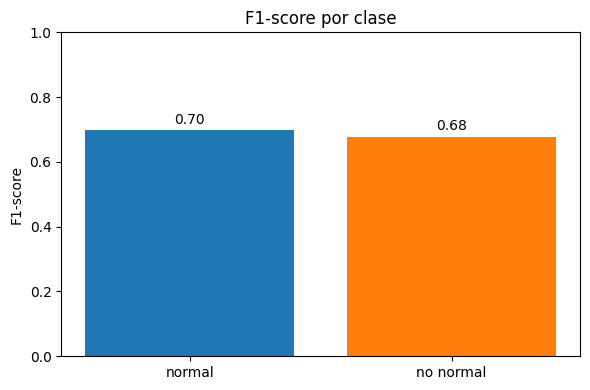

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('results_original_report.csv')
df.rename(columns={'Unnamed: 0': 'label'}, inplace=True)

# Filtrar solo normal y no normal
df_classes = df[df["label"].isin(["normal", "no normal"])]

# Valores
labels = ["normal", "no normal"]
f1_values = [
    df_classes[df_classes.label=="normal"]["f1-score"].values[0],
    df_classes[df_classes.label=="no normal"]["f1-score"].values[0]
]

# Colores para cada barra
colors = ["#1f77b4", "#ff7f0e"]  # azul y naranja (colores por defecto de matplotlib)

# --- Un solo gráfico ---
plt.figure(figsize=(6,4))
bars = plt.bar(labels, f1_values, color=colors)

# Agregar valores arriba de las barras
for bar, value in zip(bars, f1_values):
    plt.text(bar.get_x() + bar.get_width()/2,
             value + 0.02,
             f"{value:.2f}",
             ha='center')

plt.ylim(0,1)
plt.ylabel("F1-score")
plt.title("F1-score por clase")
plt.tight_layout()
plt.show()


# Ahora es tu turno de programar!

Debes ejecutar aquí la funcion `run_setting_image_shifting()` que modificaste en un bloque de codigo mas arriba.  

In [ ]:
df_results_image_shift, df_report_image_shift = run_setting_image_shifting(
    df_test, df_train, pipe, image_directory
)

if len(df_results_image_shift) > 0:
    df_results_image_shift.to_csv('results_image_shifting.csv', index=False)
    df_report_image_shift.to_csv('results_image_shifting_report.csv', index=True)
    print(f"\n[MAIN] Results saved to results_image_shifting.csv")
    print(f"[MAIN] Classification report saved to results_image_shifting_report.csv")
    print_csv_results('results_image_shifting.csv')
    print_csv_results('results_image_shifting_report.csv')

[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



SETTING: IMAGE SHIFTING (Mismatched Image + Original Text)
[LOG] Processing all 64 test samples with shifted images...
[LOG] Processing sample 1/64: UID 2469
  [LOG] Loading MISMATCHED image: 2031_IM-0676-2002.dcm.png instead of 2469_IM-0999-3001.dcm.png
  [LOG] Image loaded. Using original findings length: 272 chars
  [LOG] Making prediction with mismatched image + original text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [LOG] Prediction received: 47 chars
  [LOG] True label: 1 (no normal)
  [LOG] Predicted: NORMAL (✗)
[LOG] Processing sample 2/64: UID 2151
  [LOG] Loading MISMATCHED image: 1616_IM-0399-1002.dcm.png instead of 2151_IM-0771-1001.dcm.png
  [LOG] Image loaded. Using original findings length: 257 chars
  [LOG] Making prediction with mismatched image + original text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  [LOG] Prediction received: 47 chars
  [LOG] True label: 1 (no normal)
  [LOG] Predicted: NORMAL (✗)
[LOG] Processing sample 62/64: UID 1731
  [LOG] Loading MISMATCHED image: 3071_IM-1433-1001.dcm.png instead of 1731_IM-0481-1001.dcm.png
  [LOG] Image loaded. Using original findings length: 270 chars
  [LOG] Making prediction with mismatched image + original text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [LOG] Prediction received: 47 chars
  [LOG] True label: 1 (no normal)
  [LOG] Predicted: NORMAL (✗)
[LOG] Processing sample 63/64: UID 758
  [LOG] Loading MISMATCHED image: 3608_IM-1781-2001.dcm.png instead of 758_IM-2309-1001.dcm.png
  [LOG] Image loaded. Using original findings length: 75 chars
  [LOG] Making prediction with mismatched image + original text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [LOG] Prediction received: 47 chars
  [LOG] True label: 0 (normal)
  [LOG] Predicted: NORMAL (✓)
[LOG] Processing sample 64/64: UID 3595
  [LOG] Loading MISMATCHED image: 2028_IM-0673-1001.dcm.png instead of 3595_IM-1773-0001-0001.dcm.png
  [LOG] Image loaded. Using original findings length: 337 chars
  [LOG] Making prediction with mismatched image + original text...
  [LOG] Prediction received: 48 chars
  [LOG] True label: 1 (no normal)
  [LOG] Predicted: DISEASE (✓)

[LOG] Completed processing in 397.00 seconds

[LOG] Results Summary (IMAGE SHIFTING):
  - Total samples: 64
  - Accuracy (matching original text label): 59.38%
  - Correct predictions: 38
  - Incorrect predictions: 26

[LOG] Classification Report (F1, Precision, Recall):
              precision    recall  f1-score   support

      normal       0.46      0.83      0.59        23
   no normal       0.83      0.46      0.59        41

    accuracy                           0.59        64
   macro avg       0.64      0.64 


Debes ejecutar aqui la funcion `run_setting_text_shifting()` que modificaste en un bloque de codigo mas arriba.

In [ ]:
df_results_text_shift, df_report_text_shift = run_setting_text_shifting(
    df_test, df_train, pipe, image_directory
)
if len(df_results_text_shift) > 0:
    df_results_text_shift.to_csv('results_text_shifting.csv', index=False)
    df_report_text_shift.to_csv('results_text_shifting_report.csv', index=True)
    print(f"\n[MAIN] Results saved to results_text_shifting.csv")
    print(f"[MAIN] Classification report saved to results_text_shifting_report.csv")
    print_csv_results('results_text_shifting.csv')
    print_csv_results('results_text_shifting_report.csv')

print("\n" + "="*80)
print("All experiments completed!")
print("="*80)
print("\nGenerated files:")
print("  - results_original.csv")
print("  - results_original_report.csv")
print("  - results_image_shifting.csv")
print("  - results_image_shifting_report.csv")
print("  - results_text_shifting.csv")
print("  - results_text_shifting_report.csv")

[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



SETTING: TEXT SHIFTING (Original Image + Mismatched Text)
[LOG] Processing all 64 test samples with shifted text...
[LOG] Processing sample 1/64: UID 2469
  [LOG] Loading original image: 2469_IM-0999-3001.dcm.png
  [LOG] Mismatched findings loaded from UID 3030. Length: 183 chars
  [LOG] Making prediction with original image + mismatched text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [LOG] Prediction received: 47 chars
  [LOG] True label (Visual): 1 (no normal)
  [LOG] Predicted: NORMAL (✗)
[LOG] Processing sample 2/64: UID 2151
  [LOG] Loading original image: 2151_IM-0771-1001.dcm.png
  [LOG] Mismatched findings loaded from UID 1136. Length: 142 chars
  [LOG] Making prediction with original image + mismatched text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  [LOG] Prediction received: 47 chars
  [LOG] True label (Visual): 1 (no normal)
  [LOG] Predicted: NORMAL (✗)
[LOG] Processing sample 62/64: UID 1731
  [LOG] Loading original image: 1731_IM-0481-1001.dcm.png
  [LOG] Mismatched findings loaded from UID 3679. Length: 64 chars
  [LOG] Making prediction with original image + mismatched text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [LOG] Prediction received: 47 chars
  [LOG] True label (Visual): 1 (no normal)
  [LOG] Predicted: NORMAL (✗)
[LOG] Processing sample 63/64: UID 758
  [LOG] Loading original image: 758_IM-2309-1001.dcm.png
  [LOG] Mismatched findings loaded from UID 2919. Length: 224 chars
  [LOG] Making prediction with original image + mismatched text...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [LOG] Prediction received: 48 chars
  [LOG] True label (Visual): 0 (normal)
  [LOG] Predicted: DISEASE (✗)
[LOG] Processing sample 64/64: UID 3595
  [LOG] Loading original image: 3595_IM-1773-0001-0001.dcm.png
  [LOG] Mismatched findings loaded from UID 950. Length: 173 chars
  [LOG] Making prediction with original image + mismatched text...
  [LOG] Prediction received: 47 chars
  [LOG] True label (Visual): 1 (no normal)
  [LOG] Predicted: NORMAL (✗)

[LOG] Completed processing in 405.00 seconds

[LOG] Results Summary (TEXT SHIFTING):
  - Total samples: 64
  - Accuracy (matching original image label): 29.69%
  - Correct predictions: 19
  - Incorrect predictions: 45

[LOG] Classification Report (F1, Precision, Recall):
              precision    recall  f1-score   support

      normal       0.29      0.65      0.40        23
   no normal       0.33      0.10      0.15        41

    accuracy                           0.30        64
   macro avg       0.31      0.37      0.28        6

Como ya creaste los archivos con resultados en las celdas anteriores, debes ahora generar gráficos de resultados que se vean como estos:

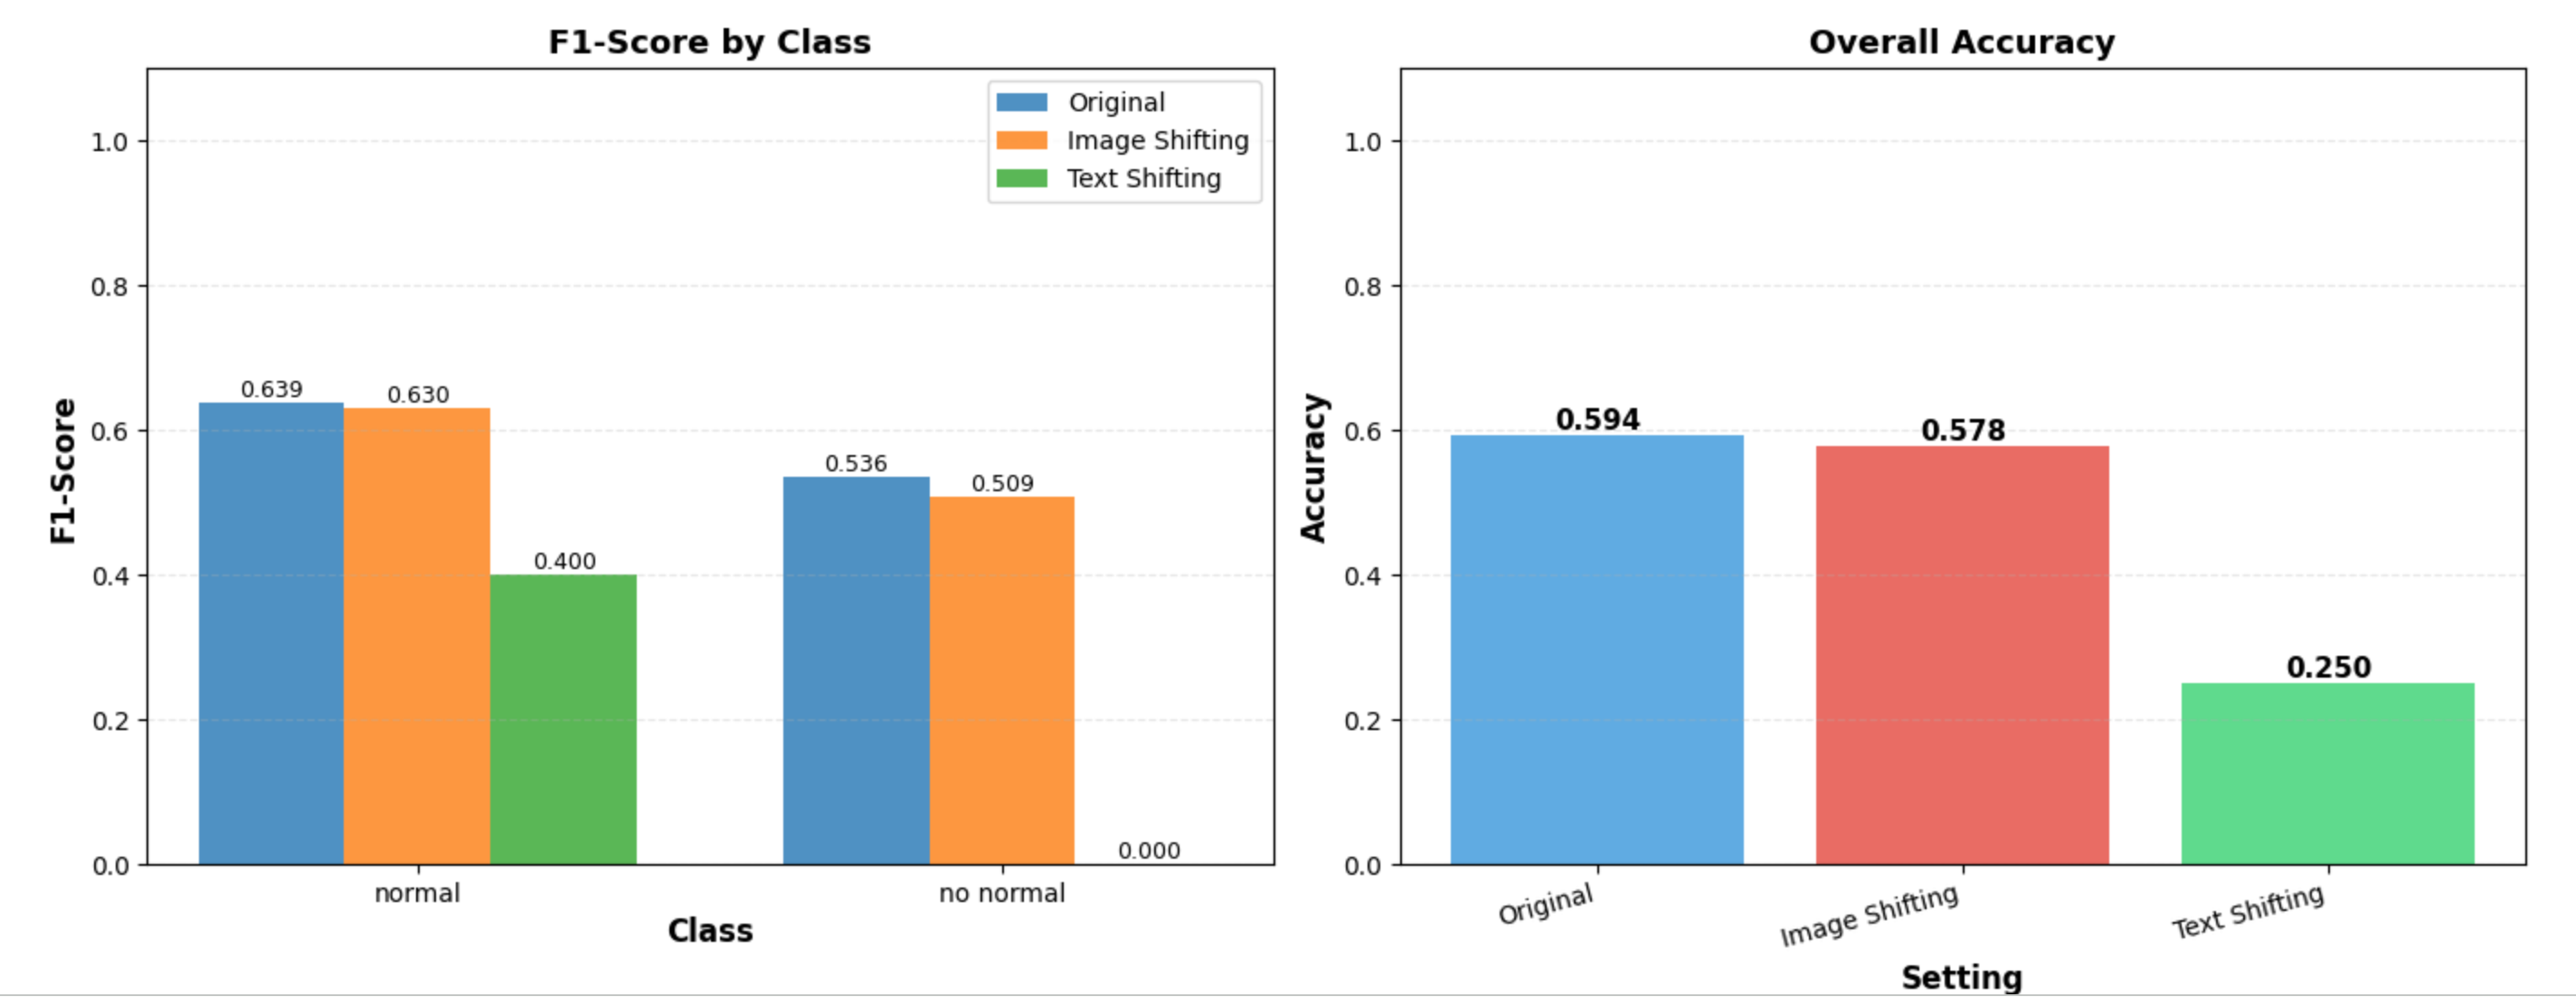

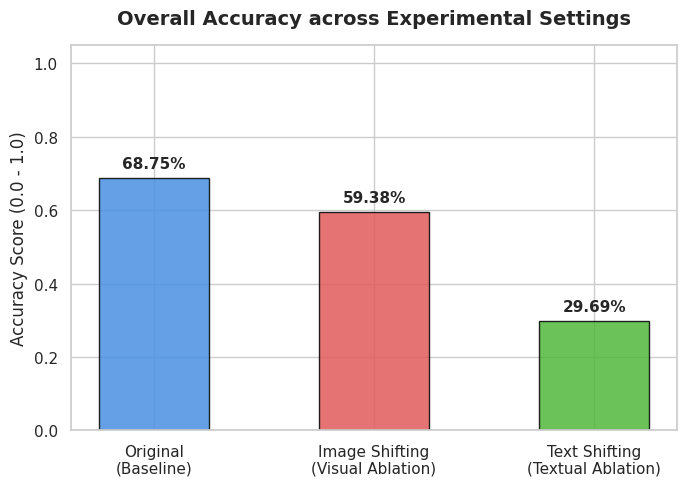

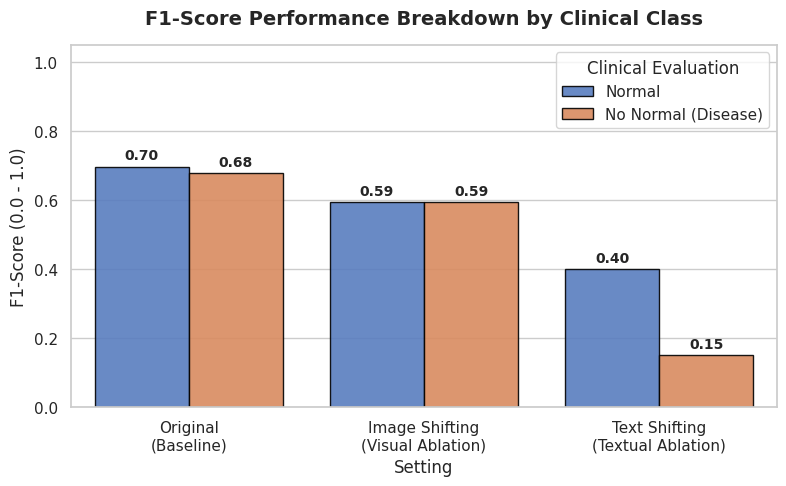


[INFO] ¡Gráficos generados con éxito! Se han guardado como 'ablation_overall_accuracy.png' y 'ablation_f1_score_by_class.png'.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

def extraer_metricas():
    # Cargar los tres reportes de clasificación guardados en disco
    rep_orig = pd.read_csv('results_original_report.csv', index_col=0)
    rep_img = pd.read_csv('results_image_shifting_report.csv', index_col=0)
    rep_txt = pd.read_csv('results_text_shifting_report.csv', index_col=0)

    # 1. Extraer la Exactitud General (Overall Accuracy)
    # En sklearn, la fila 'accuracy' guarda el valor en la columna 'precision' o 'f1-score'
    acc_orig = rep_orig.loc['accuracy', 'f1-score']
    acc_img = rep_img.loc['accuracy', 'f1-score']
    acc_txt = rep_txt.loc['accuracy', 'f1-score']

    # 2. Extraer F1-Score desglosado por clase clínica
    f1_normal = [rep_orig.loc['normal', 'f1-score'], rep_img.loc['normal', 'f1-score'], rep_txt.loc['normal', 'f1-score']]
    f1_disease = [rep_orig.loc['no normal', 'f1-score'], rep_img.loc['no normal', 'f1-score'], rep_txt.loc['no normal', 'f1-score']]

    return [acc_orig, acc_img, acc_txt], f1_normal, f1_disease

try:
    accuracies, f1_normal, f1_disease = extraer_metricas()
    escenarios = ['Original\n(Baseline)', 'Image Shifting\n(Visual Ablation)', 'Text Shifting\n(Textual Ablation)']
    colores = ['#4A90E2', '#E25B5B', '#50B83C']

    # --- GRÁFICO 1: OVERALL ACCURACY ---
    plt.figure(figsize=(7, 5))
    bars = plt.bar(escenarios, accuracies, color=colores, width=0.5, edgecolor='black', alpha=0.85)
    plt.title('Overall Accuracy across Experimental Settings', pad=15, fontweight='bold')
    plt.ylabel('Accuracy Score (0.0 - 1.0)')
    plt.ylim(0, 1.05)

    # Añadir las etiquetas numéricas arriba de cada barra
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('ablation_overall_accuracy.png', dpi=300)
    plt.show()

    # --- GRÁFICO 2: F1-SCORE BY CLINICAL CLASS ---
    # Reestructurar datos para un gráfico de barras agrupadas usando Pandas
    data_f1 = {
        'Setting': escenarios * 2,
        'F1-Score': f1_normal + f1_disease,
        'Clinical Class': ['Normal'] * 3 + ['No Normal (Disease)'] * 3
    }
    df_f1 = pd.DataFrame(data_f1)

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x='Setting', y='F1-Score', hue='Clinical Class', data=df_f1, palette='muted', edgecolor='black', alpha=0.9)
    plt.title('F1-Score Performance Breakdown by Clinical Class', pad=15, fontweight='bold')
    plt.ylabel('F1-Score (0.0 - 1.0)')
    plt.ylim(0, 1.05)
    plt.legend(title='Clinical Evaluation', loc='upper right')

    # Añadir valores numéricos sobre las barras agrupadas
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.2f}",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 8),
                        textcoords='offset points',
                        fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.savefig('ablation_f1_score_by_class.png', dpi=300)
    plt.show()

    print("\n[INFO] ¡Gráficos generados con éxito! Se han guardado como 'ablation_overall_accuracy.png' y 'ablation_f1_score_by_class.png'.")

except FileNotFoundError as e:
    print(f"\n[ERROR] No se encontraron todos los reportes necesarios. Asegúrate de ejecutar los tres escenarios primero. Detalle: {e}")

Adicionalmente, genera gráficos que permitan comparar Precision y Recall by class

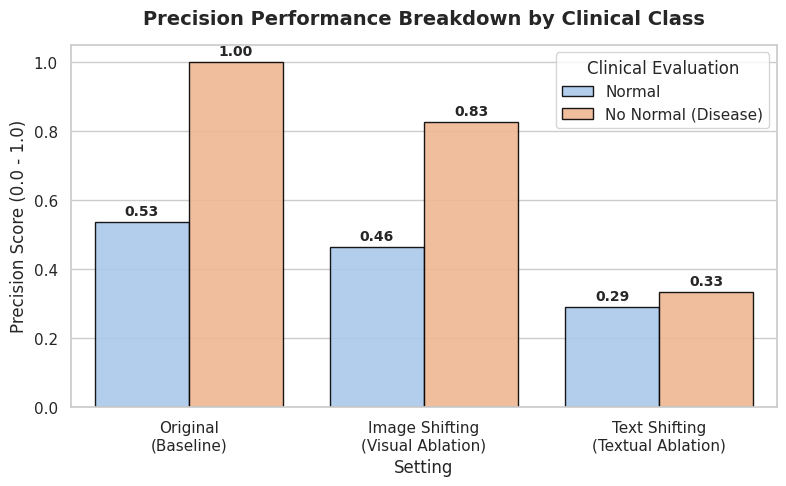

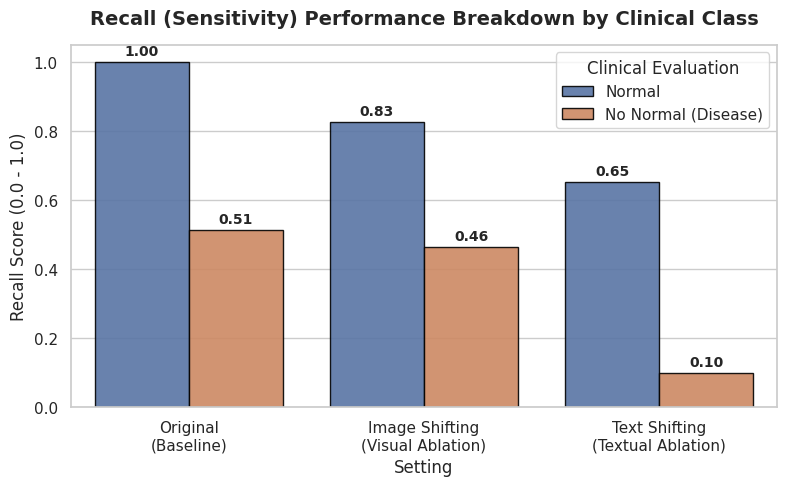


[INFO] ¡Nuevos gráficos generados con éxito! Guardados como 'ablation_precision_by_class.png' y 'ablation_recall_by_class.png'.


In [ ]:
# escribe tu codigo aqui
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

def extraer_precision_recall():
    # Cargar los tres reportes de clasificación guardados en disco
    rep_orig = pd.read_csv('results_original_report.csv', index_col=0)
    rep_img = pd.read_csv('results_image_shifting_report.csv', index_col=0)
    rep_txt = pd.read_csv('results_text_shifting_report.csv', index_col=0)

    # 1. Extraer Precision por clase para los 3 escenarios
    prec_normal = [rep_orig.loc['normal', 'precision'], rep_img.loc['normal', 'precision'], rep_txt.loc['normal', 'precision']]
    prec_disease = [rep_orig.loc['no normal', 'precision'], rep_img.loc['no normal', 'precision'], rep_txt.loc['no normal', 'precision']]

    # 2. Extraer Recall por clase para los 3 escenarios
    rec_normal = [rep_orig.loc['normal', 'recall'], rep_img.loc['normal', 'recall'], rep_txt.loc['normal', 'recall']]
    rec_disease = [rep_orig.loc['no normal', 'recall'], rep_img.loc['no normal', 'recall'], rep_txt.loc['no normal', 'recall']]

    return prec_normal, prec_disease, rec_normal, rec_disease

try:
    prec_normal, prec_disease, rec_normal, rec_disease = extraer_precision_recall()
    escenarios = ['Original\n(Baseline)', 'Image Shifting\n(Visual Ablation)', 'Text Shifting\n(Textual Ablation)']

    # --- GRÁFICO 3: PRECISION BY CLINICAL CLASS ---
    data_prec = {
        'Setting': escenarios * 2,
        'Precision Score': prec_normal + prec_disease,
        'Clinical Class': ['Normal'] * 3 + ['No Normal (Disease)'] * 3
    }
    df_prec = pd.DataFrame(data_prec)

    plt.figure(figsize=(8, 5))
    ax_p = sns.barplot(x='Setting', y='Precision Score', hue='Clinical Class', data=df_prec, palette='pastel', edgecolor='black', alpha=0.9)
    plt.title('Precision Performance Breakdown by Clinical Class', pad=15, fontweight='bold')
    plt.ylabel('Precision Score (0.0 - 1.0)')
    plt.ylim(0, 1.05)
    plt.legend(title='Clinical Evaluation', loc='upper right')

    # Añadir valores numéricos sobre las barras
    for p in ax_p.patches:
        if p.get_height() > 0:
            ax_p.annotate(f"{p.get_height():.2f}",
                          (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='center',
                          xytext=(0, 8),
                          textcoords='offset points',
                          fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.savefig('ablation_precision_by_class.png', dpi=300)
    plt.show()


    # --- GRÁFICO 4: RECALL BY CLINICAL CLASS ---
    data_rec = {
        'Setting': escenarios * 2,
        'Recall Score': rec_normal + rec_disease,
        'Clinical Class': ['Normal'] * 3 + ['No Normal (Disease)'] * 3
    }
    df_rec = pd.DataFrame(data_rec)

    plt.figure(figsize=(8, 5))
    ax_r = sns.barplot(x='Setting', y='Recall Score', hue='Clinical Class', data=df_rec, palette='deep', edgecolor='black', alpha=0.9)
    plt.title('Recall (Sensitivity) Performance Breakdown by Clinical Class', pad=15, fontweight='bold')
    plt.ylabel('Recall Score (0.0 - 1.0)')
    plt.ylim(0, 1.05)
    plt.legend(title='Clinical Evaluation', loc='upper right')

    # Añadir valores numéricos sobre las barras
    for p in ax_r.patches:
        if p.get_height() > 0:
            ax_r.annotate(f"{p.get_height():.2f}",
                          (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='center',
                          xytext=(0, 8),
                          textcoords='offset points',
                          fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.savefig('ablation_recall_by_class.png', dpi=300)
    plt.show()

    print("\n[INFO] ¡Nuevos gráficos generados con éxito! Guardados como 'ablation_precision_by_class.png' y 'ablation_recall_by_class.png'.")

except FileNotFoundError as e:
    print(f"\n[ERROR] Asegúrate de haber ejecutado los tres escenarios experimentales antes de correr esta celda. Detalle: {e}")

In [ ]:
import pandas as pd

def generar_tabla_comparativa():
    # 1. Cargar los tres reportes desde el almacenamiento de Colab
    rep_orig = pd.read_csv('results_original_report.csv', index_col=0)
    rep_img = pd.read_csv('results_image_shifting_report.csv', index_col=0)
    rep_txt = pd.read_csv('results_text_shifting_report.csv', index_col=0)

    # 2. Definir una estructura para recolectar las métricas clave
    resumen_data = []

    reportes = {
        "Original (Baseline)": rep_orig,
        "Image Shifting (Ablación Visual)": rep_img,
        "Text Shifting (Ablación Textual)": rep_txt
    }

    for escenario, df in reportes.items():
        resumen_data.append({
            "Escenario Experimental": escenario,
            "Overall Accuracy": f"{df.loc['accuracy', 'f1-score']:.2%}",
            "Precision (Normal)": f"{df.loc['normal', 'precision']:.2f}",
            "Recall (Normal)": f"{df.loc['normal', 'recall']:.2f}",
            "F1-Score (Normal)": f"{df.loc['normal', 'f1-score']:.2f}",
            "Precision (No Normal)": f"{df.loc['no normal', 'precision']:.2f}",
            "Recall (No Normal)": f"{df.loc['no normal', 'recall']:.2f}",
            "F1-Score (No Normal)": f"{df.loc['no normal', 'f1-score']:.2f}"
        })

    # 3. Crear el DataFrame consolidado
    df_comparativo = pd.DataFrame(resumen_data)

    # Guardarla también en un CSV por si la quieres descargar para Excel o LaTeX
    df_comparativo.to_csv('tabla_comparativa_ablacion.csv', index=False)

    # Mostrar la tabla estilizada en Colab
    print("\n" + "="*50)
    print(" TABLA COMPARATIVA GLOBAL DEL ESTUDIO DE ABLACIÓN")
    print("="*50 + "\n")
    display(df_comparativo)

    return df_comparativo

# Ejecutar la función
tabla_final = generar_tabla_comparativa()


 TABLA COMPARATIVA GLOBAL DEL ESTUDIO DE ABLACIÓN



,Escenario Experimental,Overall Accuracy,Precision (Normal),Recall (Normal),F1-Score (Normal),Precision (No Normal),Recall (No Normal),F1-Score (No Normal)
0,Original (Baseline),68.75%,0.53,1.00,0.70,1.00,0.51,0.68
1,Image Shifting (Ablación Visual),59.38%,0.46,0.83,0.59,0.83,0.46,0.59
2,Text Shifting (Ablación Textual),29.69%,0.29,0.65,0.40,0.33,0.10,0.15


## A continuación responde las siguientes preguntas en base a tu análisis:

1. ¿Crees que el modelo medGemma es suficientemente robusto para poder ser al menos testeado en clínica? Justifica tu respuesta en base a los resultados del análisis

*Respuesta:*
No, el modelo Med-Gemma 1.5 no es lo suficientemente robusto ni seguro para ser testeado en clínica, ni siquiera en una fase preliminar de pilotaje. La justificación empírica se sustenta en tres hallazgos críticos del análisis:



*  ***Vulnerabilidad catastrófica al sesgo textual (Shortcut Learning):*** En el escenario de Text Shifting (donde se inyectó un reporte clínico falso de signo opuesto al paciente real), el Recall para la clase patológica se desplomó a un 10.00%. Esto significa que si el personal de salud comete un error u omisión en la sospecha diagnóstica del prompt, el modelo se vuelve "ciego" a los píxeles, dejando sin detectar al 90% de los pacientes enfermos.

*  ***Asimetría de robustez y dominancia del lenguaje:*** Al alterar por completo la imagen médica (Image Shifting), la exactitud general solo disminuyó un 9.37% (quedando en 59.38%). En contraste, al alterar el texto (Text Shifting), el rendimiento se destruyó cayendo a un 29.69%. Esta disparidad demuestra que la arquitectura sobrepondera el componente lingüístico por encima del visual, fallando en el principio básico de consistencia multimodal.

*   ***Subordinación de la evidencia objetiva a la subjetiva:*** El modelo prioriza jerárquicamente el informe de texto —que en la práctica médica es una variable subjetiva, ambigua y operador-dependiente— por sobre la matriz de la radiografía, que representa la evidencia física y objetiva de la anatomía del paciente.

*Conclusión:* Al carecer de la autonomía necesaria para actuar como una segunda opinión objetiva, e incluso arrastrar un rendimiento base (Baseline) modesto del 68.75%, implementar este modelo en un flujo clínico real automatizaría y amplificaría los sesgos cognitivos humanos, introduciendo un riesgo inaceptable para la seguridad del paciente.

2. Si tu respuesta es no: ¿qué características debería mostrar el modelo antes de poder ser testeado en su uso para diagnóstico clínico?


*Respuesta:*

Para que un Modelo de Visión-Lenguaje (VLM) pueda ser considerado apto para una fase de testeo o pilotaje clínico real, debe demostrar las siguientes características de robustez y seguridad metodológica:

*  ***Robustez multimodal y resistencia al sesgo (Shifting Resistance):*** El modelo debe exhibir un equilibrio sinérgico entre la señal visual y la textual. Ante una discrepancia deliberada (Text Shifting), el sistema no debe colapsar; debe ser capaz de priorizar la radiografía objetiva para corregir el error del prompt y, idealmente, levantar una alerta de inconsistencia en lugar de asimilar el engaño de forma ciega.

*   ***Garantía métrica de seguridad (Sensibilidad crítica):*** El rendimiento base (Baseline) debe superar los estándares mínimos de la industria médica. Esto implica una Exactitud (Accuracy) global $\ge$ 85% - 90% y, fundamentalmente, una Sensibilidad (Recall) $\ge$ 90% - 95% en la clase patológica, reduciendo los falsos negativos a un margen estadísticamente seguro para evitar altas erróneas de pacientes enfermos.

*   ***Invarianza frente a la variabilidad del operador (Prompt Robustness):*** Dado que la redacción médica es subjetiva y dependiente del operador, el modelo debe mantener una predicción diagnóstica idéntica frente a un mismo caso clínico redactado con diferentes estilos, sinónimos, abreviaturas o estructuras sintácticas.


*  ***Calibración de incertidumbre y capacidad de abstención:*** El sistema debe cuantificar su nivel de confianza. Ante imágenes de baja calidad, artefactos técnicos o contradicciones insalvables entre el texto y los píxeles, el modelo debe emitir un score de confianza bajo o abstenerse de diagnosticar, derivando el caso explícitamente a un especialista humano.

*Conclusión:* En resumen, antes de ingresar a la clínica, el modelo debe demostrar de forma auditable que la evidencia física (la imagen) es el ancla inamovible de su razonamiento, relegando el texto clínico a una función puramente contextual y no jerárquicamente dominante.

 Como extra:

 La dependencia desproporcionada del modelo hacia la entrada textual resulta particularmente crítica al considerar la naturaleza de los datos en el entorno clínico. Mientras que la matriz de píxeles de una radiografía representa una evidencia física y objetiva del estado anatómico del paciente, el reporte clínico es, por definición, una variable operador-dependiente y sujeta a la subjetividad interpretativa del examinador.

 Que la arquitectura de Med-Gemma priorice la jerarquía del lenguaje sobre la evidencia visual (evidenciado por el colapso del desempeño en la condición de Text Shifting) implica que el sistema carece de la autonomía necesaria para actuar como un mecanismo de control o segunda opinión objetiva. En un escenario real, esta vulnerabilidad introduce el riesgo de automatizar y amplificar los sesgos cognitivos del personal de salud, subordinando la señal diagnóstica objetiva de la imagen a la rigidez o el error potencial del texto de entrada."

3. Si tu respuesta anterior es sí, ¿qué evaluación deberías llevar a cabo antes de ponerlo en producción?

Respuesta: